In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
import zipfile
import os
from torchvision import models
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader
import torch
from torch import nn
from torchvision import datasets
import random
from timeit import default_timer as timer
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score , classification_report


In [ ]:
dir = Path("plant_data/")
image_path = dir/"pics"
if image_path.is_dir():
  print(f"{image_path} already exists ")
else:
  print(f"{image_path} cannot exist creating one ")
  image_path.mkdir(parents=True, exist_ok=True)

plant_data/pics already exists 


In [ ]:

os.environ["KAGGLE_USERNAME"] = "hunaintahir"
os.environ["KAGGLE_KEY"]      = "KGAT_c3e7d0c18a5b83f486a4d6051d3a9e75"
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
new-plant-diseases-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip new-plant-diseases-dataset.zip -d plant_disease

Archive:  new-plant-diseases-dataset.zip
replace plant_disease/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Apple___Apple_scab/00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: nA
replace plant_disease/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Apple___Apple_scab/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
N
N
N


In [ ]:

train_dir = Path("plant_disease/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train")
test_dir  = Path("plant_disease/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid")

print(train_dir.is_dir())  # should print True
print(test_dir.is_dir())   # should print True

True
True


In [ ]:
len(list(train_dir.glob("*/*.JPG"))) , len(list(test_dir.glob("*/*.JPG")))

(67848, 16973)

In [ ]:
class_names = sorted(os.listdir(train_dir))
print(f"Number of classes: {len(class_names)}")
print(class_names)

Number of classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite

In [ ]:
weight = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weight)



In [ ]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [ ]:
# freezing the conv layers
for params in model.features.parameters():
  params.requires_grad = False

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize(256, interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

In [ ]:
test_transforms = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:

train_dataset = datasets.ImageFolder(root = train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root= test_dir , transform=test_transforms)

In [ ]:
len(train_dataset), len(test_dataset) , len(train_dataset.classes)

(70295, 17572, 38)

In [ ]:
train_dataset.class_to_idx

{'Apple___Apple_scab': 0,
 'Apple___Black_rot': 1,
 'Apple___Cedar_apple_rust': 2,
 'Apple___healthy': 3,
 'Blueberry___healthy': 4,
 'Cherry_(including_sour)___Powdery_mildew': 5,
 'Cherry_(including_sour)___healthy': 6,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
 'Corn_(maize)___Common_rust_': 8,
 'Corn_(maize)___Northern_Leaf_Blight': 9,
 'Corn_(maize)___healthy': 10,
 'Grape___Black_rot': 11,
 'Grape___Esca_(Black_Measles)': 12,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13,
 'Grape___healthy': 14,
 'Orange___Haunglongbing_(Citrus_greening)': 15,
 'Peach___Bacterial_spot': 16,
 'Peach___healthy': 17,
 'Pepper,_bell___Bacterial_spot': 18,
 'Pepper,_bell___healthy': 19,
 'Potato___Early_blight': 20,
 'Potato___Late_blight': 21,
 'Potato___healthy': 22,
 'Raspberry___healthy': 23,
 'Soybean___healthy': 24,
 'Squash___Powdery_mildew': 25,
 'Strawberry___Leaf_scorch': 26,
 'Strawberry___healthy': 27,
 'Tomato___Bacterial_spot': 28,
 'Tomato___Early_blight': 29,
 'Toma

In [ ]:
train_dataloader = DataLoader(dataset= train_dataset , batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
test_dataloader = DataLoader(dataset= test_dataset , batch_size=32 , shuffle=True, num_workers=0,pin_memory=True)

In [ ]:
len(train_dataloader), len(test_dataloader)

(2197, 550)

In [ ]:
tt=next(iter(train_dataloader))
tt[0].shape

torch.Size([32, 3, 224, 224])

In [ ]:
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(),
                             lr=0.001)

In [ ]:
def plot_random_images(dataset, class_names, n=9):
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()

    random_indices = random.sample(range(len(dataset)), n)

    for i, idx in enumerate(random_indices):
        img, label = dataset[idx]

        mean = torch.tensor([0.485, 0.456, 0.406])
        std  = torch.tensor([0.229, 0.224, 0.225])

        img = img.permute(1, 2, 0)
        img = (img * std) + mean
        img = img.clip(0, 1)

        axes[i].imshow(img)
        axes[i].set_title(class_names[label],
                         fontsize=9,
                         fontweight="bold",
                         color="green")
        axes[i].axis("off")

    plt.suptitle("Plant Disease Images",
                 fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()



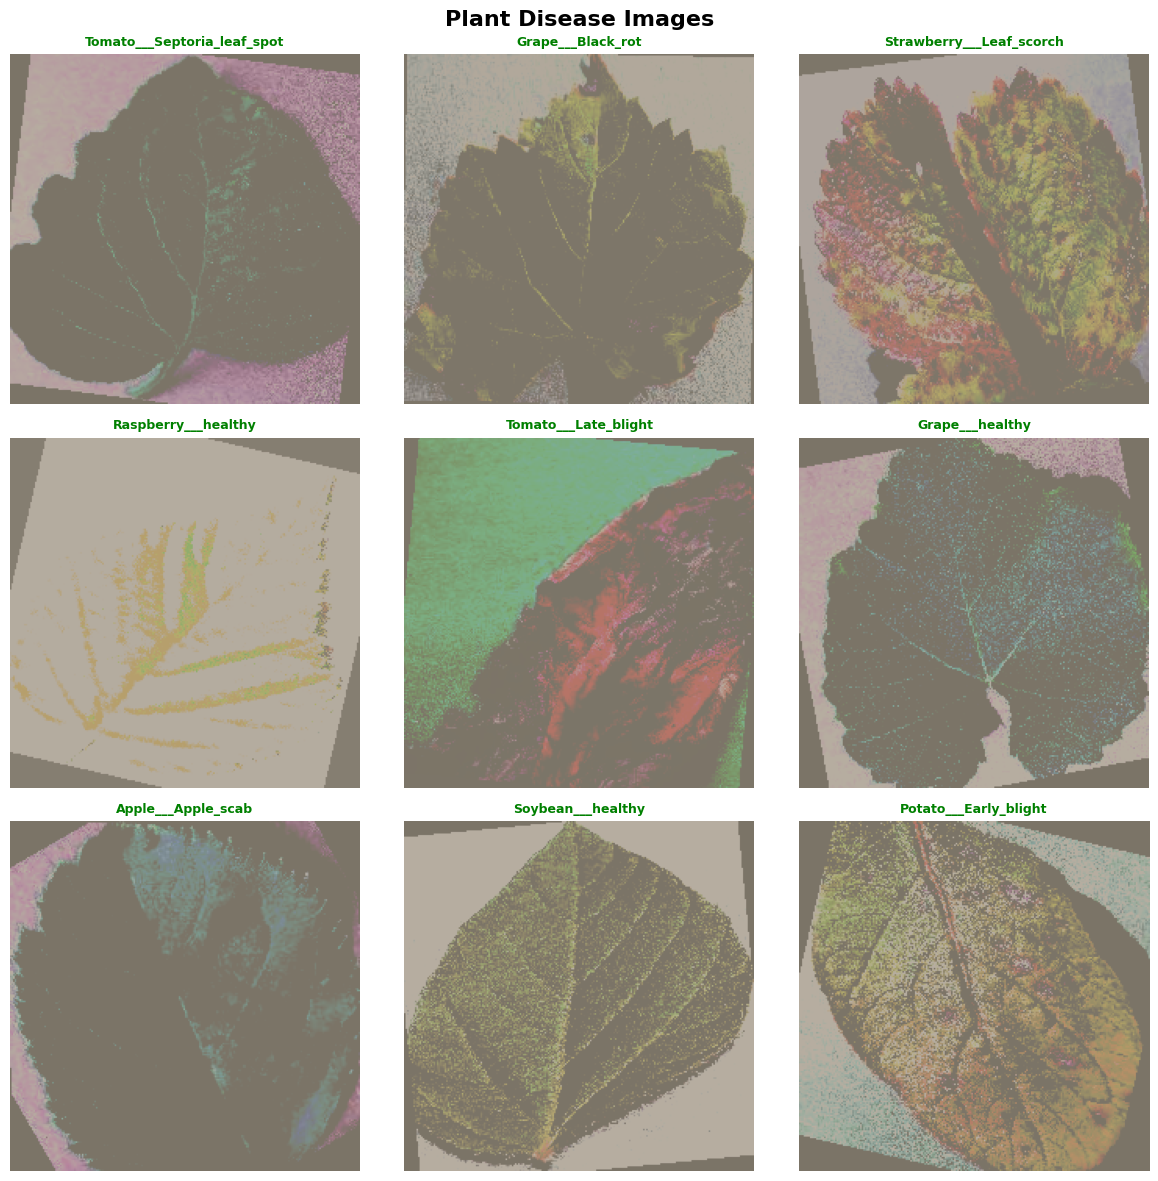

In [ ]:
plot_random_images(train_dataset, train_dataset.classes)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(1280, 38),

)

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary
summary(model, input_size=(64, 3, 224, 224))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [64, 38]                  --
├─Sequential: 1-1                                       [64, 1280, 7, 7]          --
│    └─Conv2dNormActivation: 2-1                        [64, 32, 112, 112]        --
│    │    └─Conv2d: 3-1                                 [64, 32, 112, 112]        (864)
│    │    └─BatchNorm2d: 3-2                            [64, 32, 112, 112]        (64)
│    │    └─SiLU: 3-3                                   [64, 32, 112, 112]        --
│    └─Sequential: 2-2                                  [64, 16, 112, 112]        --
│    │    └─MBConv: 3-4                                 [64, 16, 112, 112]        (1,448)
│    └─Sequential: 2-3                                  [64, 24, 56, 56]          --
│    │    └─MBConv: 3-5                                 [64, 24, 56, 56]          (6,004)
│    │    └─MBConv: 3-6                      

In [ ]:
model=model.to(device)

In [ ]:
def training(model , train_dataload , loss , optimizer , device):
    model.train()
    train_loss , train_acc = 0 ,0
    for batch , (X, y) in enumerate(train_dataload):
      X, y= X.to(device,non_blocking =True) , y.to(device, non_blocking =True)
      y_pred=model(X)
      los=loss(y_pred , y)
      train_loss+=los.item()
      acc = accuracy_score(y.cpu().detach().numpy(), torch.argmax(torch.softmax(y_pred, dim=1), dim=1 ) .cpu().detach().numpy())
      train_acc+=acc
      optimizer.zero_grad()
      los.backward()
      optimizer.step()
    train_loss/=len(train_dataload)
    train_acc/=len(train_dataload)
    return train_loss , train_acc

In [ ]:
def testing(model, test_dataload, loss, device):
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for batch, (X, y) in enumerate(test_dataload):
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            y_pred = model(X)
            los = loss(y_pred, y)
            test_loss += los.item()
            acc = accuracy_score(
                y.cpu().numpy(),
                torch.argmax(torch.softmax(y_pred, dim=1), dim=1).cpu().numpy()
            )
            test_acc += acc

        test_loss /= len(test_dataload)
        test_acc  /= len(test_dataload)
    return test_loss, test_acc

In [ ]:
def final_training(model , train_dataload , test_dataload , loss , optimizer , device , epoches):
  results = {
      "train_loss": [],
      "train_acc": [],
      "test_loss": [],
      "test_acc" : []
  }
  for epoch in tqdm(range(epoches)):
    train_loss , train_acc = training(model, train_dataload , loss , optimizer , device)
    test_loss , test_acc = testing(model , test_dataload , loss , device)
    print(f"epoch {epoch+1} | train_loss {train_loss:.4f} | train_acc {train_acc:.4f} | test_loss {test_loss:.4f} | test_acc {test_acc:.4f}")
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)
  return results



In [ ]:
from torch.utils.data import Subset

small_train = Subset(train_dataset, range(5000))
small_test  = Subset(test_dataset, range(1000))

small_train_loader = DataLoader(
    small_train,
    batch_size=32,
    shuffle=True,
    num_workers=0
)
small_test_loader = DataLoader(
    small_test,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [ ]:

weights = models.EfficientNet_B0_Weights.DEFAULT
model   = models.efficientnet_b0(weights=weights)

for param in model.features.parameters():
    param.requires_grad = False
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(1280, 38))
model = model.to(device)
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

In [ ]:
print(f"Test batches: {len(test_dataloader)}")
print(f"Test samples: {len(test_dataset)}")

Test batches: 550
Test samples: 17572


In [ ]:
print(f"Device: {device}")
print(f"Model device: {next(model.parameters()).device}")


X, y = next(iter(train_dataloader))
print(f"Data device: {X.device}")

Device: cuda
Model device: cuda:0
Data device: cpu


In [ ]:
!pip install GPUtil
import GPUtil
GPUtil.showUtilization()

| ID | GPU | MEM |
------------------
|  0 |  0% |  7% |


In [ ]:
results = final_training(model , small_train_loader,small_test_loader , loss_fn , optimizer, device , epoches=10)

  0%|          | 0/10 [00:00<?, ?it/s]

epoch 1 | train_loss 0.5470 | train_acc 0.8814 | test_loss 0.1290 | test_acc 0.9834
epoch 2 | train_loss 0.1574 | train_acc 0.9676 | test_loss 0.0724 | test_acc 0.9883
epoch 3 | train_loss 0.1080 | train_acc 0.9761 | test_loss 0.0565 | test_acc 0.9902
epoch 4 | train_loss 0.0875 | train_acc 0.9805 | test_loss 0.0413 | test_acc 0.9893
epoch 5 | train_loss 0.0755 | train_acc 0.9835 | test_loss 0.0317 | test_acc 0.9922
epoch 6 | train_loss 0.0714 | train_acc 0.9817 | test_loss 0.0317 | test_acc 0.9932
epoch 7 | train_loss 0.0575 | train_acc 0.9853 | test_loss 0.0305 | test_acc 0.9932
epoch 8 | train_loss 0.0605 | train_acc 0.9831 | test_loss 0.0281 | test_acc 0.9932
epoch 9 | train_loss 0.0602 | train_acc 0.9825 | test_loss 0.0309 | test_acc 0.9932
epoch 10 | train_loss 0.0559 | train_acc 0.9827 | test_loss 0.0252 | test_acc 0.9941


In [ ]:
print(f"Test batches: {len(test_dataloader)}")
print(f"Test samples: {len(test_dataset)}")

Test batches: 550
Test samples: 17572


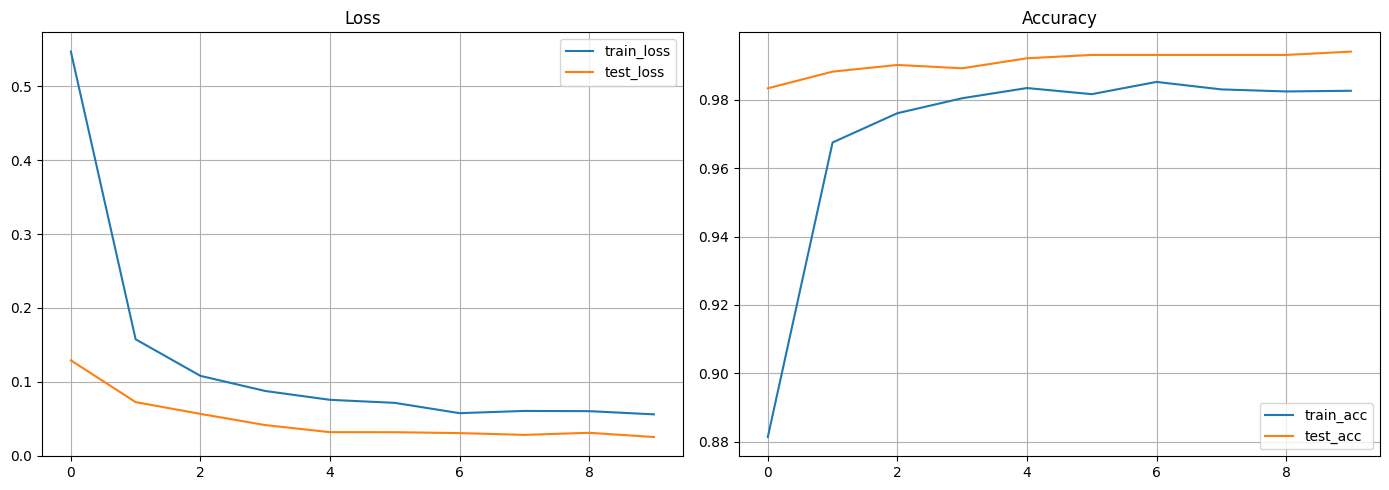

In [ ]:
def plot_loss_curves(results):
    epochs = range(len(results["train_loss"]))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs, results["train_loss"], label="train_loss")
    ax1.plot(epochs, results["test_loss"],  label="test_loss")
    ax1.set_title("Loss"); ax1.legend(); ax1.grid(True)
    ax2.plot(epochs, results["train_acc"], label="train_acc")
    ax2.plot(epochs, results["test_acc"],  label="test_acc")
    ax2.set_title("Accuracy"); ax2.legend(); ax2.grid(True)
    plt.tight_layout()
    plt.show()

plot_loss_curves(results)

In [ ]:
torch.save(model.state_dict(), "plant_disease_model.pth")
